<a href="https://colab.research.google.com/github/brenoassis32/GoogleColab-Coliop-CMPL/blob/main/Exemplo_Videoaula_pyCmpl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial - Coliop - Parte 2b - Programando modelos na forma algébrica no Google Colab

# 1. Configuração do Ambiente

Nesta etapa, configuramos o ambiente do Google Colab para utilizar a linguagem  **CMPL**.

Essa célula deve ser executada apenas:
- Ao abrir o notebook pela primeira vez
- Ou quando o ambiente for reiniciado/desconectado

O que será feito:
- Download do COLIOP/CMPL (disponível em [coliop.org](https://www.coliop.org/download.html))
- Extração dos arquivos
- Configuração de variáveis de ambiente
- Inclusão das bibliotecas no Python

In [ ]:
### Esta célula dever ser executada apenas quando o notebook for aberto
### ou quando o ambiente for desconectado e for necessário reconectá-lo
### por inatividade!

# Importação de bibliotecas do sistema
import os, sys

# Baixa o pacote do CMPL a partir do site oficial
os.system("wget https://www.coliop.org/_download/Cmpl-2-1-0-linux64.tar.gz")

# Extrai o arquivo baixado
os.system("tar -xzf Cmpl-2-1-0-linux64.tar.gz")

# Define o diretório principal do CMPL
os.environ["CMPLHOME"] = "/content/Cmpl-2-1-0-linux64"

# Adiciona o executável do CMPL ao PATH do sistema
os.environ["PATH"] += ":/content/Cmpl-2-1-0-linux64/bin"

# Configura bibliotecas compartilhadas necessárias
os.environ["LD_LIBRARY_PATH"] = "/content/Cmpl-2-1-0-linux64/bin/lib:" + os.environ.get("LD_LIBRARY_PATH", "")

# Adiciona os módulos Python do CMPL ao caminho de importação
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/lib3")
sys.path.append("/content/Cmpl-2-1-0-linux64/pyCmpl/scripts/Unix")

# 2. Definição do Modelo de Otimização (Exemplo do Tutorial)

Aqui definimos um problema de **programação linear inteira** usando a linguagem CMPL.

## 2.1 Objetivo:
Maximizar a receita total da produção de produtos.

## 2.2 Elementos do modelo:
- **Produtos**: itens que podem ser produzidos
- **Recursos**: insumos limitados
- **Preço**: lucro por unidade
- **Capacidade**: limite de recursos disponíveis
- **Consumo**: quanto cada produto usa de cada recurso
- **Limite superior**: máximo de produção por produto

## 2.3 Variável de decisão:
- `x[j]`: quantidade produzida do produto `j`

In [ ]:
# Definição do modelo em linguagem CMPL (como string)
codigo_cmpl = """
par:

# Conjuntos
Produtos:=set(1,2);
Recursos:=set(1,2);

# Parâmetros
PRECO[Produtos]:=(75,100);              # Receita por produto
CAPACIDADE[Recursos]:=(350,800);       # Capacidade dos recursos
CONSUMO[Recursos,Produtos]:=((1.5,2),(3,4));  # Consumo de recursos por produto
LIMITE_S[Produtos]:=(1000,150);        # Limite máximo de produção

var:

# Variáveis de decisão (inteiras e não negativas)
x[Produtos]: int[0..];

obj:

# Função objetivo: maximizar a receita total
receita:sum{j in Produtos: PRECO[j]*x[j]} -> max;

con:

# Restrição de capacidade dos recursos
DispRecursos{i in Recursos:
    sum{j in Produtos: CONSUMO[i,j]*x[j]} <= CAPACIDADE[i];
}

# Restrição de limite superior de produção
LimiteSuperior{j in Produtos:
    x[j] <= LIMITE_S[j];
}
"""

# Salva o modelo em um arquivo .cmpl
with open("/content/exemplo_videoaula01.cmpl", "w") as f:
    f.write(codigo_cmpl)

# 3. Resolução do Modelo

Nesta etapa utilizamos a **API Python pyCmpl** para fazer a integração entre modelo e resolvedor:
1. Carregamos o modelo criado
2. Executamos o solver
3. Exibimos o relatório da solução
4. Tratamento de erro para capturar possíveis problemas.

Também é possível fazer a entrada de dados por um arquivo python, atribuindo valores para conjuntos e parâmetros do modelo, utilizando atributos e métodos do pyCmpl. Isto será objeto para outra aula.

In [ ]:
# Importa a biblioteca do CMPL para Python
from pyCmpl import *

try:
    # Cria o objeto do modelo a partir do arquivo
    modelo = Cmpl("/content/exemplo_videoaula01.cmpl")

    # Resolve o problema de otimização
    modelo.solve()

    # Exibe o relatório da solução (valores ótimos)
    modelo.solutionReport()

except CmplException as e:
    # Caso ocorra erro, exibe a mensagem
    print(e.msg)

---------------------------------------------------------------------------------------------------------
Problem              exemplo_videoaula01.cmpl
Nr. of variables     2
Nr. of constraints   4
Objective name       receita
Solver name          HIGHS
Display variables    (all)
Display constraints  (all)
---------------------------------------------------------------------------------------------------------

Objective status     INTEGER OPTIMAL
Objective value      17500.00            (max!)

Variables           
Name                 Type            Activity          LowerBound          UpperBound            Marginal
---------------------------------------------------------------------------------------------------------
x[1]                    I                  36                0.00             1000.00                   -
x[2]                    I                 148                0.00              150.00                   -
------------------------------------------------------

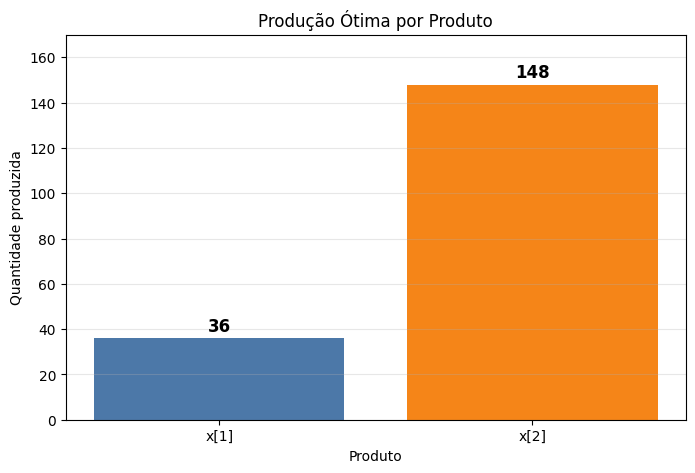

In [ ]:
import matplotlib.pyplot as plt

# Seleciona as variáveis x do modelo
variaveis_x = [
    v for v in modelo.solution.variables
    if v.name.startswith("x[")
]

produtos = [v.name for v in variaveis_x]
quantidades = [v.activity for v in variaveis_x]

plt.figure(figsize=(8,5))

barras = plt.bar(produtos, quantidades, color=['#4C78A8', '#F58518'])

plt.title('Produção Ótima por Produto')
plt.xlabel('Produto')
plt.ylabel('Quantidade produzida')

for barra, valor in zip(barras, quantidades):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        valor + 3,
        str(valor),
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.ylim(0, 170)
plt.grid(axis='y', alpha=0.3)

plt.show()

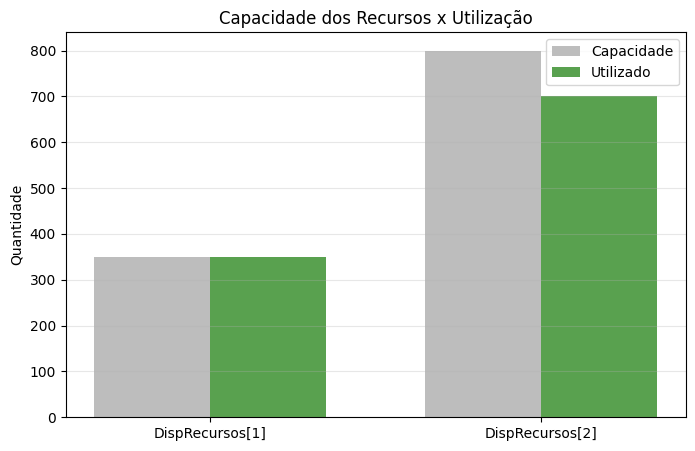

In [ ]:
restricoes_recursos = [
    c for c in modelo.solution.constraints
    if c.name.startswith("DispRecursos[")
]

recursos = [c.name for c in restricoes_recursos]
utilizado = [c.activity for c in restricoes_recursos]
capacidade = [c.upperBound for c in restricoes_recursos]


x = range(len(recursos))
largura = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    [i - largura/2 for i in x],
    capacidade,
    width=largura,
    label='Capacidade',
    color='#BDBDBD'
)

plt.bar(
    [i + largura/2 for i in x],
    utilizado,
    width=largura,
    label='Utilizado',
    color='#59A14F'
)

plt.xticks(list(x), recursos)
plt.ylabel('Quantidade')
plt.title('Capacidade dos Recursos x Utilização')
plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.show()

# Source code

The source code is available on Github:
Cmpl official realeases: https://github.com/coin-or/Cmpl

Cmpl working git: https://github.com/MikeSteglich/Cmpl2

Coliop: https://github.com/MikeSteglich/Coliop

pyCmpl: https://github.com/MikeSteglich/pyCmpl3